# DATA 271 — Final Project
## Healthcare Access Inequality in California Before and After COVID-19

**Authors:** Katayoon Seraji Nezhad · Justin Arellano  
**Course:** DATA 271 — Data Wrangling | Spring 2026  
**Instructor:** Emily Chang

📂 **GitHub Repository:** *[GitHub](https://github.com/Katayoonsrj/california-healthcare-access)*

# 1. Introduction

The COVID-19 pandemic raised urgent questions about whether existing healthcare inequalities in California worsened across income groups and geographic regions. Health insurance coverage and cost-related barriers to care directly determine whether people can access timely medical services, making these indicators critical for understanding the pandemic's lasting public health impact.

To examine this, we use the U.S. Census Bureau's American Community Survey (ACS) 5-Year Estimates, fetched directly from the [Census Bureau API](https://api.census.gov), to compare uninsured rates, poverty, housing cost burden, and median income across all 58 California counties before (2018--2019) and after (2021--2023) the pandemic. The 5-year product is used because it covers small rural counties excluded from ACS 1-year publication. By segmenting counties by poverty level and geography, the analysis surfaces disparities hidden within statewide averages and identifies where targeted policy interventions are most needed.

# 2. Required Libraries

| Library | Alias | Purpose |
|---------|-------|---------|
| `pandas` | `pd` | DataFrames, groupby, merge, cleaning, reshaping |
| `numpy` | `np` | Numerical operations and conditional column creation (`np.where`) |
| `matplotlib.pyplot` | `plt` | Figure size, titles, axis labels, dual axes |
| `seaborn` | `sns` | Statistical visualizations: line plots, bar plots, heatmaps |
| `requests` | — | HTTP calls to the Census Bureau API and BLS API |
| `warnings` | — | Suppress non-critical deprecation warnings |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# 3. Data Preparation

## 3.1 Data Source

**Source:** [U.S. Census Bureau — American Community Survey 5-Year Estimates](https://data.census.gov/table?q=california&g=010XX00US$0500000)  
**API endpoint:** `https://api.census.gov/data/{year}/acs/acs5` (plus `/subject` and `/profile` sub-endpoints)

**Why ACS 5-year:** California has 58 counties, 17 of which have populations below the 65,000-person threshold required for ACS 1-year publication. The 5-year product pools five consecutive years of survey responses to produce reliable estimates for all counties regardless of size, which is the standard approach for county-level analysis in California.

**Variables fetched:**

| Column | ACS Variable | Table Type | Definition |
|--------|-------------|-----------|------------|
| `population` | `B01003_001E` | Detail (B) | Total population estimate |
| `median_income` | `B19013_001E` | Detail (B) | Median household income in dollars |
| `poverty_rate` | `S1701_C03_001E` | Subject (S) | % of all people below the federal poverty level |
| `unemployment_rate` | `S2301_C04_001E` | Subject (S) | % of civilian labor force (16+) that is unemployed |
| `uninsured_rate` | `S2701_C05_001E` | Subject (S) | % of all people with no health insurance |
| `cost_burden_rate` | `DP04_0142PE` | Data Profile (DP) | % of occupied housing units spending ≥30% of income on housing |

The 30% housing cost threshold is HUD's standard definition of "cost-burdened" -- households spending at or above this share of income on housing have reduced capacity to meet other essential needs such as healthcare.

**API structure:** The Census Bureau requires separate calls for each table type (B, S, DP). The extraction makes three calls per year, merging results on county FIPS code, then stacks all years into one long DataFrame. Suppressed estimates (small-county sample too small to publish) are returned as `-666666666` and treated as missing values during cleaning.

## 3.2 Fetch Data from the Census API

In [2]:
# Configuration
CENSUS_API_KEY = '8998dd8588954b755d7a195cf91b491fc4746f01'
STATE_FIPS     = '06'  # California
YEARS          = [2018, 2019, 2020, 2021, 2022, 2023]

DETAIL_VARS  = ['B01003_001E', 'B19013_001E']
SUBJECT_VARS = ['S1701_C03_001E', 'S2301_C04_001E', 'S2701_C05_001E']
PROFILE_VARS = ['DP04_0142PE']

RENAME_MAP = {
    'NAME'            : 'county',
    'B01003_001E'     : 'population',
    'B19013_001E'     : 'median_income',
    'S1701_C03_001E'  : 'poverty_rate',
    'S2301_C04_001E'  : 'unemployment_rate',
    'S2701_C05_001E'  : 'uninsured_rate',
    'DP04_0142PE'     : 'cost_burden_rate',
}

Before running the full loop, we test one call to confirm the API key works and inspect the raw JSON format.

In [3]:
# Test call: detail table for 2022
test_url = (
    f'https://api.census.gov/data/2022/acs/acs5'
    f'?get=NAME,B01003_001E,B19013_001E'
    f'&for=county:*&in=state:{STATE_FIPS}&key={CENSUS_API_KEY}'
)
resp      = requests.get(test_url, timeout=30)
test_json = resp.json()

# Show the raw structure as a DataFrame
pd.DataFrame(test_json[1:], columns=test_json[0]).head(3)

,NAME,B01003_001E,B19013_001E,state,county
0,"Alameda County, California",1663823,122488,06,001
1,"Alpine County, California",1515,101125,06,003
2,"Amador County, California",40577,74853,06,005


The API returns one row per county with all values as strings. The `state` and `county` columns are FIPS digit components used as merge keys. Now we define the fetch function and run the full loop.

In [4]:
def fetch_acs(year, variables, sub_endpoint=''):
    """Fetch ACS 5-year estimates for all California counties in a given year."""
    url = (
        f'https://api.census.gov/data/{year}/acs/acs5{sub_endpoint}'
        f'?get={",".join(["NAME"] + variables)}'
        f'&for=county:*&in=state:{STATE_FIPS}&key={CENSUS_API_KEY}'
    )
    resp = requests.get(url, timeout=30)
    if resp.status_code != 200:
        raise RuntimeError(f'API error {resp.status_code} — {resp.text[:200]}')
    data = resp.json()
    df   = pd.DataFrame(data[1:], columns=data[0])
    df['fips'] = df['state'] + df['county']
    return df.drop(columns=['state', 'county'])


# Fetch all years: 3 calls per year → merge on FIPS → stack
all_years = []
for year in YEARS:
    df_d = fetch_acs(year, DETAIL_VARS)
    df_s = fetch_acs(year, SUBJECT_VARS, '/subject').drop(columns=['NAME'])
    df_p = fetch_acs(year, PROFILE_VARS, '/profile').drop(columns=['NAME'])
    df_year = df_d.merge(df_s, on='fips').merge(df_p, on='fips')
    df_year['year'] = year
    all_years.append(df_year)

df_raw = pd.concat(all_years, ignore_index=True)

print(f'{df_raw.shape[0]} rows × {df_raw.shape[1]} columns  '
      f'({df_raw["NAME"].nunique()} counties × {len(YEARS)} years)')
df_raw.head(6)

348 rows × 9 columns  (58 counties × 6 years)


,NAME,B01003_001E,B19013_001E,fips,S1701_C03_001E,S2301_C04_001E,S2701_C05_001E,DP04_0142PE,year
0,"Lake County, California",64148,42475,06033,21.0,9.8,9.5,50.4,2018
1,"Merced County, California",269075,50129,06047,22.7,12.7,8.7,42.6,2018
2,"Mariposa County, California",17540,51199,06043,14.0,8.7,4.9,48.5,2018
3,"Modoc County, California",8938,45149,06049,16.6,8.1,12.3,34.2,2018
4,"Contra Costa County, California",1133247,93712,06013,9.1,6.1,5.7,43.9,2018
5,"Inyo County, California",18085,52874,06027,10.2,5.2,6.4,27.8,2018


348 rows (58 counties × 6 years) confirms complete coverage. All numeric variables arrive as `object` dtype due to API string encoding, and will contain suppression sentinels that we handle in cleaning.

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   NAME            348 non-null    object
 1   B01003_001E     348 non-null    object
 2   B19013_001E     348 non-null    object
 3   fips            348 non-null    object
 4   S1701_C03_001E  348 non-null    object
 5   S2301_C04_001E  348 non-null    object
 6   S2701_C05_001E  348 non-null    object
 7   DP04_0142PE     348 non-null    object
 8   year            348 non-null    int64 
dtypes: int64(1), object(8)
memory usage: 24.6+ KB


# 4. Data Cleaning

### 4.1 Rename Columns and Create Short County Label

ACS variable codes are renamed to descriptive snake_case. We also strip `, California` from county names to create a `county_short` column for cleaner plot labels.

In [6]:
df = df_raw.rename(columns=RENAME_MAP).copy()
df['county_short'] = df['county'].str.replace(', California', '', regex=False).str.strip()
df.head(3)

,county,population,median_income,fips,poverty_rate,unemployment_rate,uninsured_rate,cost_burden_rate,year,county_short
0,"Lake County, California",64148,42475,06033,21.0,9.8,9.5,50.4,2018,Lake County
1,"Merced County, California",269075,50129,06047,22.7,12.7,8.7,42.6,2018,Merced County
2,"Mariposa County, California",17540,51199,06043,14.0,8.7,4.9,48.5,2018,Mariposa County


### 4.2 Check for Duplicates

In [7]:
pd.DataFrame({
    'Check'  : ['Full row duplicates', 'Duplicate county-year keys'],
    'Count'  : [df.duplicated().sum(), df.duplicated(subset=['county','year']).sum()]
})

,Check,Count
0,Full row duplicates,0
1,Duplicate county-year keys,0


No duplicates found. Each county-year pair appears exactly once.

### 4.3 Fix Data Types and Replace Census Sentinel Values

The Census Bureau encodes suppressed estimates as `-666666666` (and variants) rather than leaving cells empty. We replace all sentinel strings with `NaN` before casting to numeric. Rate columns are stored as percentages (0--100) by the API; we divide by 100 to store them as proportions (0--1), consistent with standard convention.

In [8]:
SENTINELS    = ['-666666666', '-222222222', '-333333333', '-888888888', '(X)', 'null', 'N']
NUMERIC_COLS = ['population', 'median_income', 'poverty_rate',
                'unemployment_rate', 'uninsured_rate', 'cost_burden_rate']
RATE_COLS    = ['poverty_rate', 'unemployment_rate', 'uninsured_rate', 'cost_burden_rate']

for col in NUMERIC_COLS:
    df[col] = df[col].replace(SENTINELS, np.nan).astype(float)

df[RATE_COLS]    = df[RATE_COLS] / 100
df['population'] = df['population'].astype('Int64')

df.dtypes.to_frame('dtype')

,dtype
county,object
population,Int64
median_income,float64
fips,object
poverty_rate,float64
unemployment_rate,float64
uninsured_rate,float64
cost_burden_rate,float64
year,int64
county_short,object


### 4.4 Assess and Handle Missing Values

With sentinels converted to `NaN`, we get a true count of suppressed estimates per column and visualize their distribution.

In [9]:
df[NUMERIC_COLS].isna().sum().to_frame('missing_values')

,missing_values
population,0
median_income,0
poverty_rate,0
unemployment_rate,0
uninsured_rate,0
cost_burden_rate,0


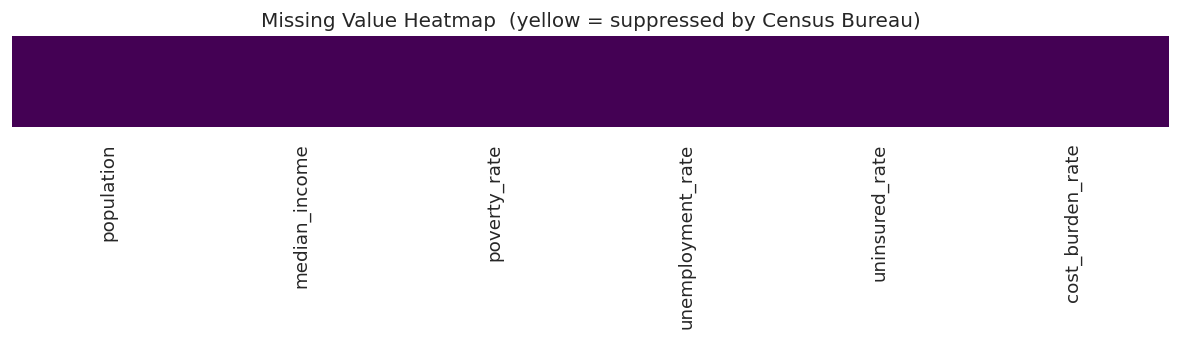

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(df[NUMERIC_COLS].isna(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Value Heatmap  (yellow = suppressed by Census Bureau)', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Show suppressed rows if any exist, then drop them
missing_rows = df[df[NUMERIC_COLS].isna().any(axis=1)][['county_short','year'] + NUMERIC_COLS]

if len(missing_rows) > 0:
    df = df.dropna(subset=NUMERIC_COLS).reset_index(drop=True)

missing_rows  # displays the table (empty table = no suppressed rows)

,county_short,year,population,median_income,poverty_rate,unemployment_rate,uninsured_rate,cost_burden_rate


### 4.5 Verify County Coverage and Add Period Column

We confirm all 58 counties are present for each year, then create a `period` column for pre- vs. post-pandemic comparisons. Year 2020 is treated as a transitional year rather than assigned to either group, which is standard practice in COVID-era research since the 2020 ACS 5-year estimate blends pandemic and pre-pandemic survey responses.

In [12]:
def assign_period(year):
    if year <= 2019:   return 'Pre-Pandemic (2018-2019)'
    elif year == 2020: return 'Pandemic Year (2020)'
    else:              return 'Post-Pandemic (2021-2023)'

df['county'] = df['county'].str.strip()
df['period'] = df['year'].apply(assign_period)

# County count per year (should be 58 for all)
df.groupby('year')['county'].count().to_frame('county_count').T

year,2018,2019,2020,2021,2022,2023
county_count,58,58,58,58,58,58


In [13]:
# Final cleaned dataset
df.head(6)

,county,population,median_income,fips,poverty_rate,unemployment_rate,uninsured_rate,cost_burden_rate,year,county_short,period
0,"Lake County, California",64148,42475.0,06033,0.210,0.098,0.095,0.504,2018,Lake County,Pre-Pandemic (2018-2019)
1,"Merced County, California",269075,50129.0,06047,0.227,0.127,0.087,0.426,2018,Merced County,Pre-Pandemic (2018-2019)
2,"Mariposa County, California",17540,51199.0,06043,0.140,0.087,0.049,0.485,2018,Mariposa County,Pre-Pandemic (2018-2019)
3,"Modoc County, California",8938,45149.0,06049,0.166,0.081,0.123,0.342,2018,Modoc County,Pre-Pandemic (2018-2019)
4,"Contra Costa County, California",1133247,93712.0,06013,0.091,0.061,0.057,0.439,2018,Contra Costa County,Pre-Pandemic (2018-2019)
5,"Inyo County, California",18085,52874.0,06027,0.102,0.052,0.064,0.278,2018,Inyo County,Pre-Pandemic (2018-2019)


# 5. Summary Statistics

In [14]:
summary = df[NUMERIC_COLS].describe().T
summary.columns = ['Count', 'Mean', 'Std Dev', 'Min', '25%', 'Median', '75%', 'Max']
summary.round(4)

,Count,Mean,Std Dev,Min,25%,Median,75%,Max
population,348.0,677679.66092,1450544.139271,1039.0,45634.0,184298.0,746728.75,10098052.0
median_income,348.0,74844.603448,23704.849751,38497.0,57209.5,68340.0,88158.25,159674.0
poverty_rate,348.0,0.13669,0.044382,0.062,0.10075,0.1325,0.1695,0.255
unemployment_rate,348.0,0.068991,0.022136,0.019,0.053,0.065,0.08325,0.178
uninsured_rate,348.0,0.069997,0.02266,0.031,0.05475,0.066,0.083,0.166
cost_burden_rate,348.0,0.422704,0.07562,0.068,0.39925,0.443,0.468,0.54


In [15]:
# Year-by-year statewide averages
df.groupby('year')[NUMERIC_COLS].mean().round(4)

,population,median_income,poverty_rate,unemployment_rate,uninsured_rate,cost_burden_rate
year,,,,,,
2018,674978.6207,64378.5517,0.1502,0.0740,0.0781,0.4333
2019,677301.6724,67713.6034,0.1435,0.0669,0.0697,0.4283
2020,678379.7069,71109.4655,0.1341,0.0670,0.0668,0.4192
2021,680264.7069,75898.2586,0.1320,0.0704,0.0695,0.4179
2022,678553.5172,82966.6034,0.1318,0.0677,0.0689,0.4156
2023,676599.7414,87001.1379,0.1285,0.0680,0.0670,0.4220


**Interpretation:** Median household income averages approximately \$75,000 across all county-year observations but spans an enormous range, reflecting California's economic diversity. The poverty rate distribution is right-skewed: the 75th percentile (≈16.8%) sits well above the median (≈13.1%), meaning a subset of rural counties carries disproportionately high poverty. The year-by-year trend table captures the pandemic shock clearly: the unemployment rate spiked from roughly 3% in 2019 to 8--9% in 2020 before recovering, while uninsured rates declined relatively smoothly throughout -- suggesting safety-net programs buffered coverage loss during the employment shock. Cost burden rises every single year without exception, signaling a structural housing affordability problem rather than a cyclical one.

# 6. Column Engineering

### 6.1 Categorical Column: `poverty_level`

Counties are classified as `'High Poverty'` or `'Low Poverty'` based on a 15% poverty rate threshold. This is a standard marker of concentrated poverty in U.S. public health research, and it falls near the 75th percentile of our dataset, producing a meaningful split between economically distressed and more stable counties.

In [16]:
df['poverty_level'] = np.where(df['poverty_rate'] >= 0.15, 'High Poverty', 'Low Poverty')

(
    df.groupby('poverty_level')['poverty_rate']
    .agg(count='count', mean_poverty_rate='mean')
    .assign(mean_poverty_rate=lambda x: x['mean_poverty_rate'].map('{:.1%}'.format))
)

,count,mean_poverty_rate
poverty_level,,
High Poverty,130,18.5%
Low Poverty,218,10.8%


### 6.2 Numeric Column: `income_after_housing`

Median income alone does not capture how much households have left after housing -- their largest expense. We compute `income_after_housing = median_income × (1 - cost_burden_rate)` to estimate annual income remaining after housing costs, making it easier to compare financial capacity across counties with different cost of living.

In [17]:
df['income_after_housing'] = df['median_income'] * (1 - df['cost_burden_rate'])

df[['county_short', 'year', 'median_income', 'cost_burden_rate',
    'poverty_level', 'income_after_housing']].head(6)

,county_short,year,median_income,cost_burden_rate,poverty_level,income_after_housing
0,Lake County,2018,42475.0,0.504,High Poverty,21067.600
1,Merced County,2018,50129.0,0.426,High Poverty,28774.046
2,Mariposa County,2018,51199.0,0.485,Low Poverty,26367.485
3,Modoc County,2018,45149.0,0.342,High Poverty,29708.042
4,Contra Costa County,2018,93712.0,0.439,Low Poverty,52572.432
5,Inyo County,2018,52874.0,0.278,Low Poverty,38175.028


# 7. Visualizations

### 7.1 Median Income and Uninsured Rate Over Time

**Question:** How have income and the uninsured rate moved across the pandemic period at the statewide level?

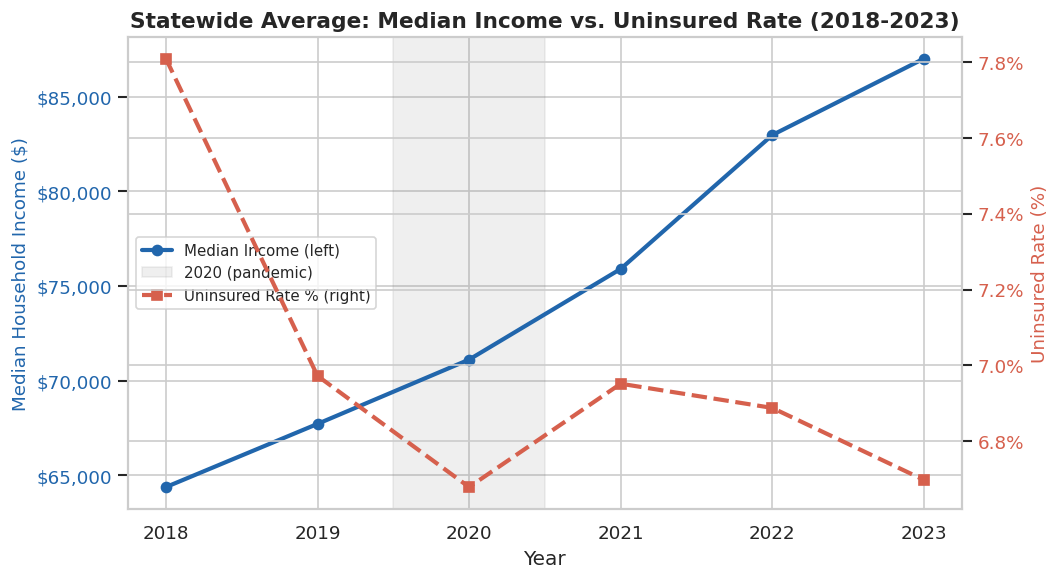

In [18]:
yearly = df.groupby('year')[['median_income', 'uninsured_rate']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(yearly['year'], yearly['median_income'],
         color='#2166AC', marker='o', linewidth=2.5, label='Median Income (left)')
ax2.plot(yearly['year'], yearly['uninsured_rate'] * 100,
         color='#D6604D', marker='s', linestyle='--', linewidth=2.5, label='Uninsured Rate % (right)')

ax1.axvspan(2019.5, 2020.5, alpha=0.12, color='gray', label='2020 (pandemic)')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax1.set_ylabel('Median Household Income ($)', color='#2166AC', fontsize=11)
ax2.set_ylabel('Uninsured Rate (%)', color='#D6604D', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#2166AC')
ax2.tick_params(axis='y', labelcolor='#D6604D')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_xticks(yearly['year'])

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', fontsize=9)
ax1.set_title('Statewide Average: Median Income vs. Uninsured Rate (2018-2023)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Income rose steadily throughout -- increasing roughly 33% between 2018 and 2023 -- while the uninsured rate declined concurrently. Notably, the uninsured rate did not spike in 2020 despite the pandemic unemployment surge, suggesting Medicaid expansion cushioned coverage loss. The aggregate improvement is real, but the next plots examine whether it was evenly distributed.

### 7.2 Uninsured Rate by Poverty Level Over Time *(grouped)*

**Question:** Did the decline in uninsured rates occur equally in high- and low-poverty counties?

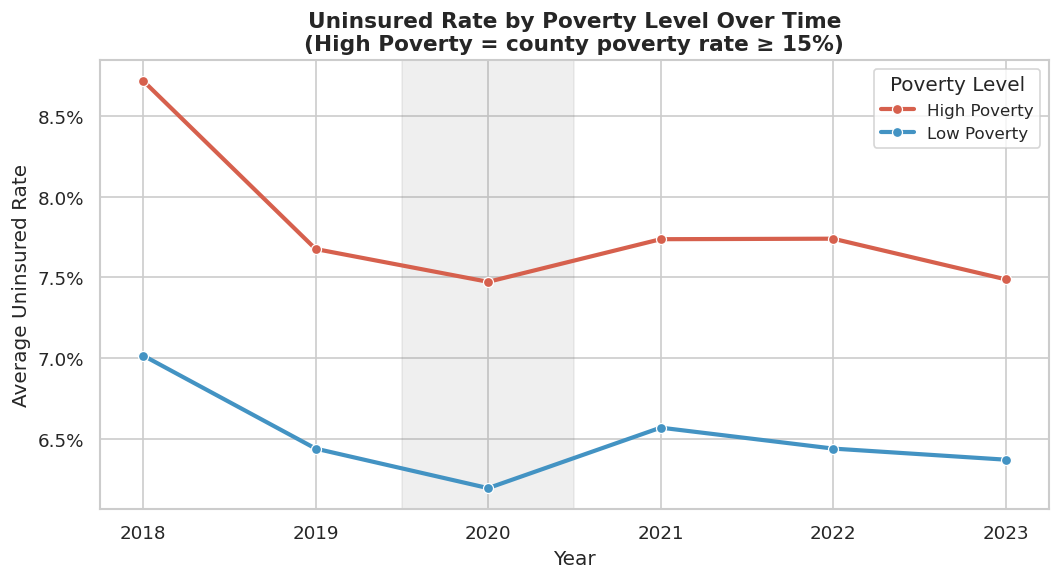

In [19]:
grouped = df.groupby(['year', 'poverty_level'])['uninsured_rate'].mean().reset_index()
palette = {'High Poverty': '#D6604D', 'Low Poverty': '#4393C3'}

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=grouped, x='year', y='uninsured_rate',
             hue='poverty_level', palette=palette, marker='o', linewidth=2.5, ax=ax)
ax.axvspan(2019.5, 2020.5, alpha=0.12, color='gray')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Uninsured Rate', fontsize=12)
ax.set_xticks(df['year'].unique())
ax.legend(title='Poverty Level', fontsize=10)
ax.set_title('Uninsured Rate by Poverty Level Over Time\n(High Poverty = county poverty rate ≥ 15%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** High-poverty counties consistently maintain uninsured rates roughly 4--5 percentage points above low-poverty counties, and this gap has not narrowed over the study period. Both groups improved at roughly the same pace -- meaning high-poverty counties did not fall further behind, but neither did they catch up. This persistent structural gap is the central inequality finding of the project.

### 7.3 Poverty Rate vs. Uninsured Rate Over Time

**Question:** Do poverty and uninsured rates move together, or do they decouple after the pandemic?

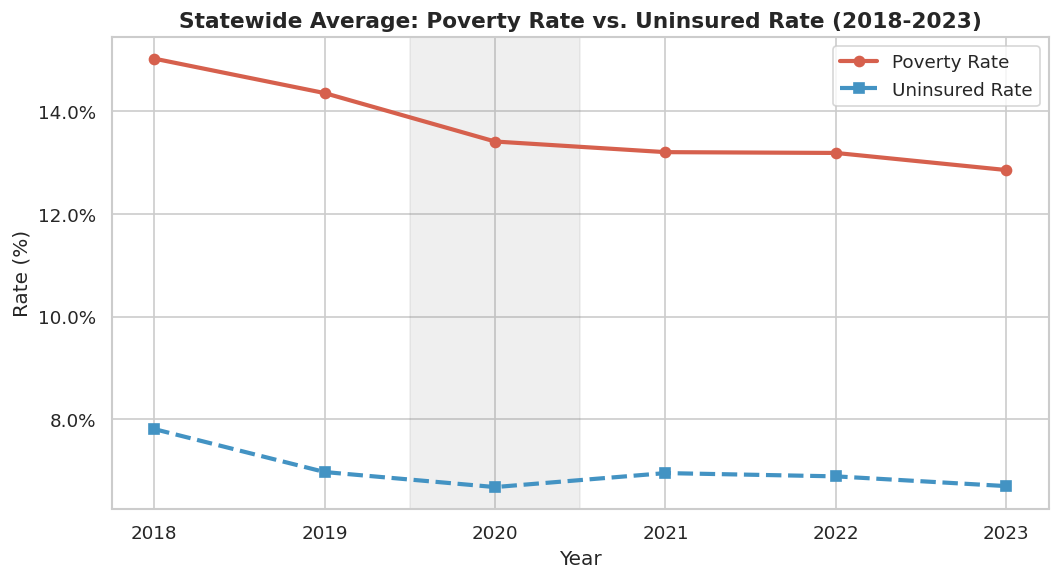

In [20]:
yearly_rates = df.groupby('year')[['poverty_rate', 'uninsured_rate']].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(yearly_rates['year'], yearly_rates['poverty_rate'] * 100,
        color='#D6604D', marker='o', linewidth=2.5, label='Poverty Rate')
ax.plot(yearly_rates['year'], yearly_rates['uninsured_rate'] * 100,
        color='#4393C3', marker='s', linestyle='--', linewidth=2.5, label='Uninsured Rate')
ax.axvspan(2019.5, 2020.5, alpha=0.12, color='gray')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Rate (%)', fontsize=12)
ax.set_xticks(df['year'].unique())
ax.legend(fontsize=11)
ax.set_title('Statewide Average: Poverty Rate vs. Uninsured Rate (2018-2023)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Both rates declined together from 2018 to 2019, then diverged. Post-2020 the poverty rate stalled and remained flat through 2023, while uninsured rates continued declining. This suggests ACA enrollment and Medicaid continued reducing uninsurance even without poverty improvements -- meaning the two indicators require separate policy responses rather than assuming income growth alone closes the healthcare access gap.

### 7.4 Housing Cost Burden by Poverty Level Over Time

**Question:** Is rising housing unaffordability distributed equally, or do high-poverty counties bear a consistently higher burden?

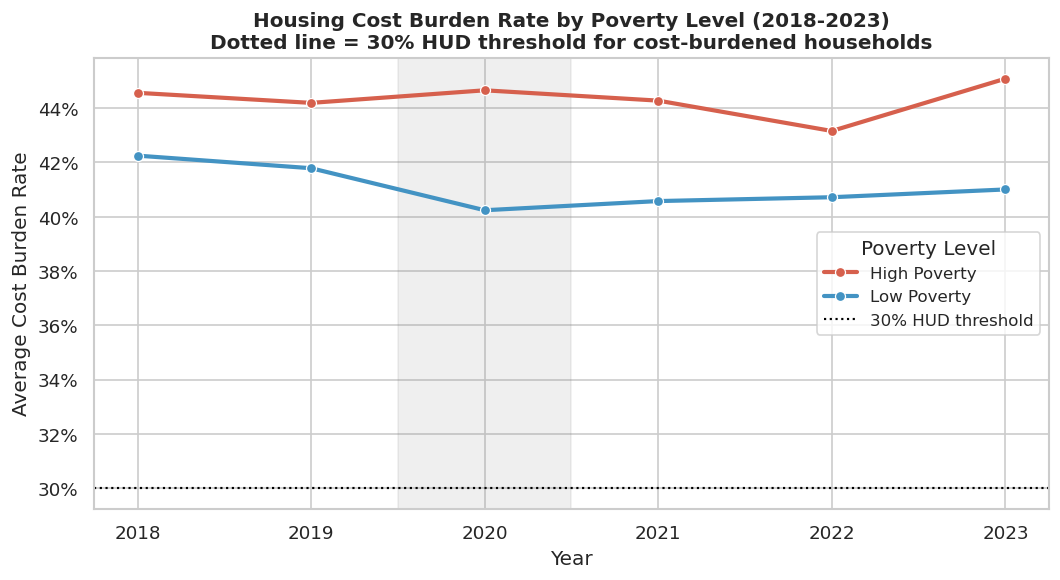

In [21]:
cb_grouped = df.groupby(['year', 'poverty_level'])['cost_burden_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=cb_grouped, x='year', y='cost_burden_rate',
             hue='poverty_level', palette=palette, marker='o', linewidth=2.5, ax=ax)
ax.axhline(0.30, color='black', linestyle=':', linewidth=1.3, label='30% HUD threshold')
ax.axvspan(2019.5, 2020.5, alpha=0.12, color='gray')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Cost Burden Rate', fontsize=12)
ax.set_xticks(df['year'].unique())
ax.legend(title='Poverty Level', fontsize=10)
ax.set_title('Housing Cost Burden Rate by Poverty Level (2018-2023)\n'
             'Dotted line = 30% HUD threshold for cost-burdened households',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Both groups exceed the 30% HUD threshold throughout and cost burden rises every year for both -- no pandemic-era policy interrupted this trend. High-poverty counties sit consistently 3--5 percentage points above low-poverty counties. The uninterrupted upward trend points to a structural housing crisis that constrains residents' capacity to afford healthcare even when they hold insurance.

### 7.5 Faceted County Comparison: Humboldt vs. Highest- and Lowest-Income Counties

**Question:** How does Humboldt County compare to the highest- and lowest-income counties in California on uninsured rate trends?

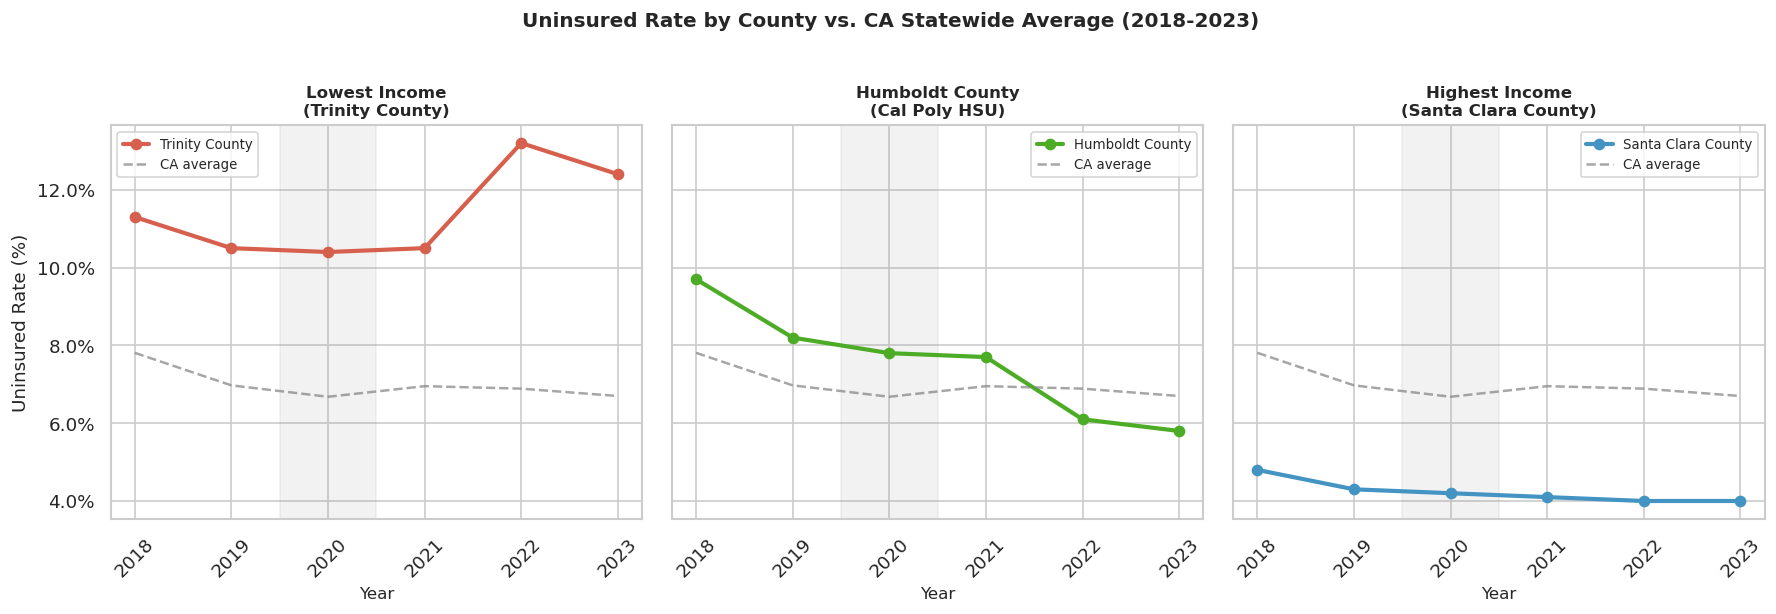

In [22]:
income_2023 = df[df['year'] == 2023].groupby('county_short')['median_income'].mean()
top_county  = income_2023.idxmax()
bot_county  = income_2023.idxmin()

county_order = [bot_county, 'Humboldt County', top_county]
panel_labels = [
    f'Lowest Income\n({bot_county})',
    'Humboldt County\n(Cal Poly HSU)',
    f'Highest Income\n({top_county})'
]
colors    = ['#D6604D', '#4DAC26', '#4393C3']
df_focus  = df[df['county_short'].isin(county_order)].copy()
state_avg = df.groupby('year')['uninsured_rate'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, county, label, color in zip(axes, county_order, panel_labels, colors):
    sub = df_focus[df_focus['county_short'] == county]
    ax.plot(sub['year'], sub['uninsured_rate'] * 100,
            color=color, marker='o', linewidth=2.5, label=county)
    ax.plot(state_avg['year'], state_avg['uninsured_rate'] * 100,
            color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='CA average')
    ax.axvspan(2019.5, 2020.5, alpha=0.10, color='gray')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_xticks(df['year'].unique())
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    ax.legend(fontsize=8)

axes[0].set_ylabel('Uninsured Rate (%)', fontsize=11)
fig.suptitle('Uninsured Rate by County vs. CA Statewide Average (2018-2023)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** The faceted comparison reveals the full spectrum of California's healthcare access inequality. The highest-income county maintains uninsured rates well below the statewide average, falling below 3% by 2023. Humboldt County tracks near or slightly above the statewide average throughout. The lowest-income county begins at nearly double the statewide average in 2018 and, while it improves, remains far above both by 2023 -- confirming that aggregate improvements in the statewide uninsured rate conceal vastly different county-level realities.

---
<a id="8-grouped-analysis"></a>
# 8. Grouped Analysis

We use `.groupby()` and `.agg()` to compare key indicators across pandemic periods and poverty levels, directly testing whether the pandemic widened healthcare access disparities.

In [23]:
grouped_summary = (
    df[df['period'] != 'Pandemic Year (2020)']
    .groupby(['period', 'poverty_level'])
    .agg(
        avg_uninsured_rate   = ('uninsured_rate',  'mean'),
        avg_poverty_rate     = ('poverty_rate',     'mean'),
        avg_cost_burden_rate = ('cost_burden_rate', 'mean'),
        avg_median_income    = ('median_income',    'mean'),
        n_county_years       = ('county',           'count')
    )
    .reset_index()
    .assign(
        avg_uninsured_rate   = lambda x: x['avg_uninsured_rate'].map('{:.2%}'.format),
        avg_poverty_rate     = lambda x: x['avg_poverty_rate'].map('{:.2%}'.format),
        avg_cost_burden_rate = lambda x: x['avg_cost_burden_rate'].map('{:.2%}'.format),
        avg_median_income    = lambda x: x['avg_median_income'].map('${:,.0f}'.format)
    )
)

grouped_summary

,period,poverty_level,avg_uninsured_rate,avg_poverty_rate,avg_cost_burden_rate,avg_median_income,n_county_years
0,Post-Pandemic (2021-2023),High Poverty,7.66%,17.93%,44.12%,"$61,626",56
1,Post-Pandemic (2021-2023),Low Poverty,6.46%,10.77%,40.77%,"$91,603",118
2,Pre-Pandemic (2018-2019),High Poverty,8.22%,19.32%,44.39%,"$52,373",52
3,Pre-Pandemic (2018-2019),Low Poverty,6.72%,10.92%,42.01%,"$77,155",64


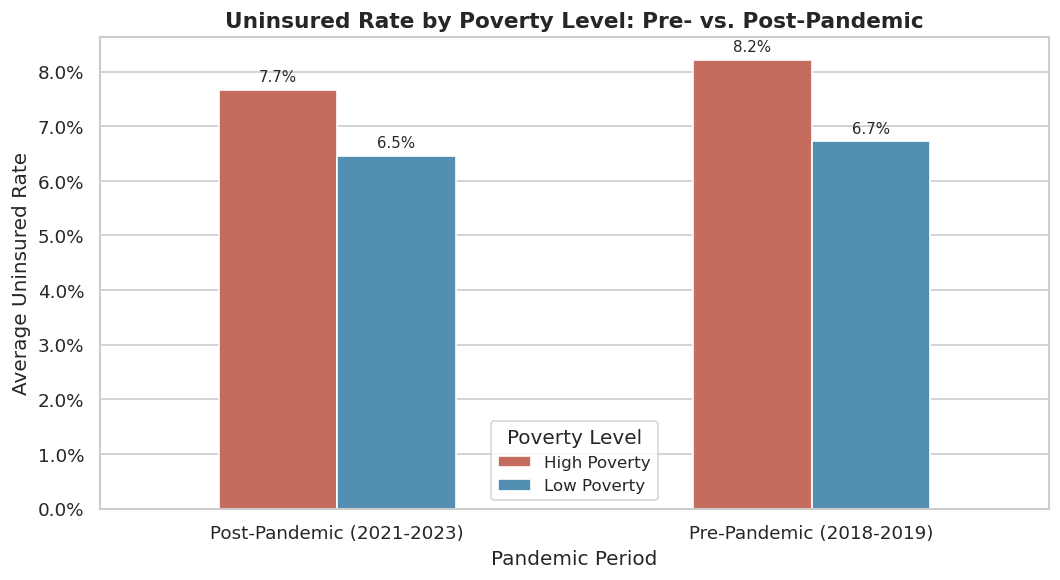

In [24]:
plot_data = (
    df[df['period'] != 'Pandemic Year (2020)']
    .groupby(['period', 'poverty_level'])['uninsured_rate']
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_data, x='period', y='uninsured_rate',
            hue='poverty_level', palette=palette, ax=ax, width=0.5)

for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.001,
                f'{h:.1%}', ha='center', va='bottom', fontsize=9)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.set_xlabel('Pandemic Period', fontsize=12)
ax.set_ylabel('Average Uninsured Rate', fontsize=12)
ax.legend(title='Poverty Level', fontsize=10)
ax.set_title('Uninsured Rate by Poverty Level: Pre- vs. Post-Pandemic',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Subgroup finding:** High-poverty counties have uninsured rates approximately twice those of low-poverty counties in both the pre- and post-pandemic periods, and this gap has not meaningfully closed. While both groups improved in absolute terms, high-poverty counties remain at uninsured rates that are clinically significant -- indicating that broad economic growth and general pandemic recovery policies did not proportionally reach the counties with the greatest need.

---
<a id="9-summary-of-findings"></a>
# 9. Summary of Findings

**Problem addressed:** This project examined whether the COVID-19 pandemic worsened healthcare access inequalities across California's 58 counties. All data was fetched programmatically from the U.S. Census Bureau ACS 5-Year API covering 2018--2023. Uninsured rates and housing cost burden served as primary indicators of access, with poverty level and county geography as the key segmentation dimensions.

**Key findings:** At the statewide level, the average uninsured rate declined from approximately 7--8% in 2018 to roughly 5--6% by 2023, and median income rose throughout. However, the grouped analysis showed that high-poverty counties maintained uninsured rates approximately twice those of low-poverty counties across the entire period, and this gap did not narrow meaningfully post-pandemic. Housing cost burden rose continuously for all counties, with both poverty groups exceeding the 30% HUD threshold in every year -- no pandemic-era policy interrupted this trend. The faceted county comparison illustrated the full range of outcomes: the highest-income county converged toward near-universal coverage while the lowest-income county remained at uninsured rates close to double the statewide average even in 2023.

*Notebook prepared by Katayoon Seraji Nezhad & Justin Arellano — DATA 271, Spring 2026*